In [ ]:
#NAME YASHRAJ VIJAY TURAKNE

In [ ]:
#SPOTIFY MUSIC RECOMMENDATION SYSTEM..

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(r"C:\Users\Global\Downloads\spotify dataset.csv")

In [3]:
df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [12]:
df.shape


(32833, 23)

In [13]:
df.describe

<bound method NDFrame.describe of                      track_id  \
0      6f807x0ima9a1j3VPbc7VN   
1      0r7CVbZTWZgbTCYdfa2P31   
2      1z1Hg7Vb0AhHDiEmnDE79l   
3      75FpbthrwQmzHlBJLuGdC7   
4      1e8PAfcKUYoKkxPhrHqw4x   
...                       ...   
32828  7bxnKAamR3snQ1VGLuVfC1   
32829  5Aevni09Em4575077nkWHz   
32830  7ImMqPP3Q1yfUHvsdn7wEo   
32831  2m69mhnfQ1Oq6lGtXuYhgX   
32832  29zWqhca3zt5NsckZqDf6c   

                                              track_name      track_artist  \
0      I Don't Care (with Justin Bieber) - Loud Luxur...        Ed Sheeran   
1                        Memories - Dillon Francis Remix          Maroon 5   
2                        All the Time - Don Diablo Remix      Zara Larsson   
3                      Call You Mine - Keanu Silva Remix  The Chainsmokers   
4                Someone You Loved - Future Humans Remix     Lewis Capaldi   
...                                                  ...               ...   
32828               Cit

In [14]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
"""The Spotify dataset is a rich collection of track data designed for music analysis and building recommendation systems.
General OverviewTotal Records: 32,833 unique song entries (after initial cleaning).
Total Attributes: 23 columns, including identifiers (ID, Name, Artist), metadata (Album, Release Date), and technical audio features.
Key Identification Columns: track_id, track_name, track_artist, playlist_genre, and playlist_name.
Genre DistributionThe dataset is well-balanced across six primary musical genres, making it ideal for classification and grouping
EDM: 6,043 songsRap: 5,746 songsPop: 5,507 songsR&B: 5,431 songsLatin: 5,155 songsRock: 4,951 songs"""

In [10]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0])
has_nulls = df.isnull().values.any()
total_nulls = df.isnull().sum().sum()
print(f"Total number of null values: {total_nulls}")

Null values per column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64
Total number of null values: 15


In [ ]:
#THEIR ARE TOTAL 15 NULL VALUES IN COLUMNS 3 COLUMNS HAS NULL VALUES EACH COLUMN INCLUDES 5
#COLUMNS ARE track_name=5,track_artist=5,track_album_name=5.

In [18]:
df_cleaned = df.dropna()
print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")
print(f"Total rows removed: {len(df) - len(df_cleaned)}")
df_cleaned.to_csv('spotify_cleaned.csv', index=False)
df.dropna(inplace=True)

Original row count: 32833
Cleaned row count: 32828
Total rows removed: 5


In [ ]:
#WE REMOVES 5 ROWS FROM DATASET TO HANDLE NULL VALUES AND MAKE OUR DATA CLEAN .

In [20]:
print("Null values per column:")
print(df.isnull().sum())
total_nulls = df.isnull().sum().sum()
print(f"\nTotal null values in the dataset: {total_nulls}")

Null values per column:
track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

Total null values in the dataset: 0


In [ ]:
#AS OUTPUT THEIR IS NO NULL VALUES IN DATASET NOW.SO WE GOOD TO GO FOR VISUALIZATION ...

C:\Users\Global\AppData\Local\Temp\ipykernel_16544\3493335108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='playlist_genre', palette='Set2', order=df['playlist_genre'].value_counts().index)


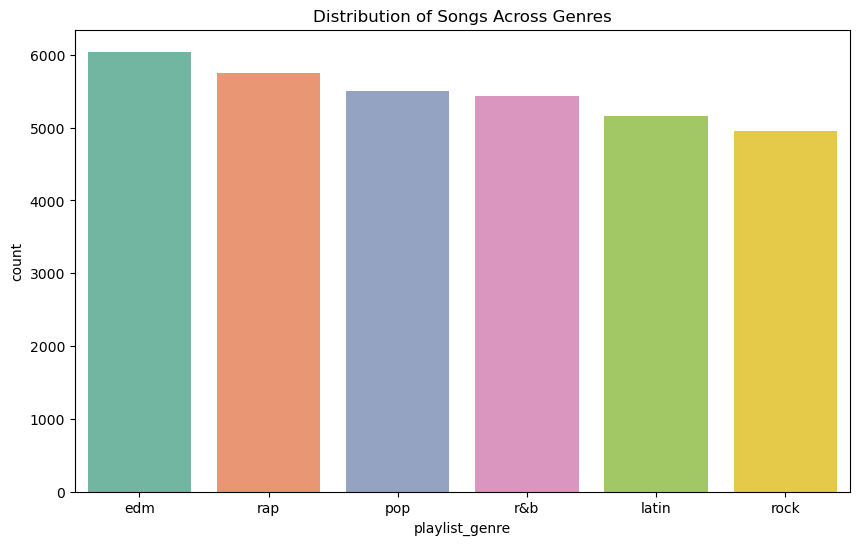

In [21]:
# Visualizes which genres have the most representation in the dataset.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='playlist_genre', palette='Set2', order=df['playlist_genre'].value_counts().index)
plt.title('Distribution of Songs Across Genres')
plt.savefig('genre_distribution.png')

In [ ]:
"""This chart tells us that the dataset isn't biased toward just one type of music.
it has a healthy variety of all six major genres, which makes  clustering model more accurate."""

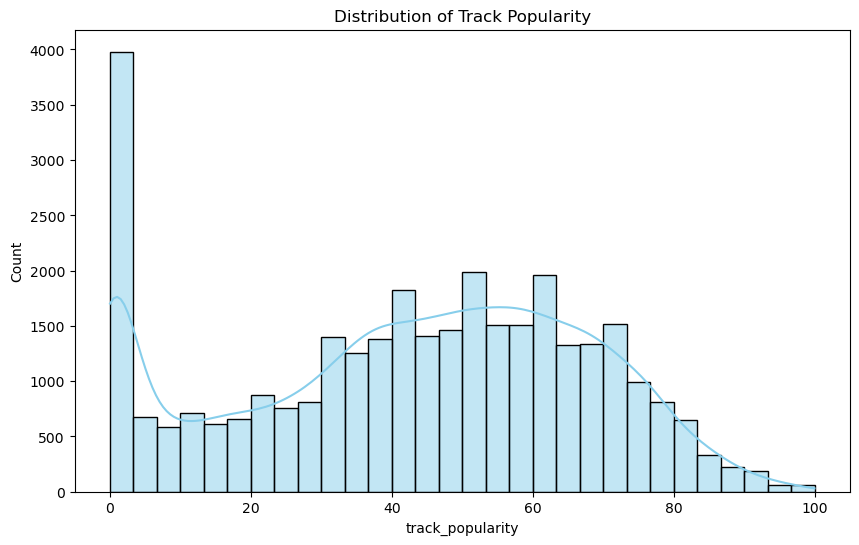

In [22]:
# Shows how "hits" compare to less popular songs.
plt.figure(figsize=(10, 6))
sns.histplot(df['track_popularity'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Track Popularity')
plt.savefig('popularity_distribution.png')

In [ ]:
"""Average Popularity: Most songs have a popularity score between 30 and 60.
This is where the "hump" or the highest part of the chart is located
The "Zero" Spike: There is a noticeable spike at the very beginning 0. 
This means a large number of songs have no popularity score, possibly because they are brand new or very obscure.
The Super-Hits: The chart gets very thin as it approaches 100. This shows that "super-hit" songs are quite rare in the dataset.
Overall Shape: The distribution looks somewhat like a bell curve, but it is skewed by the many songs that have a score of zero."""

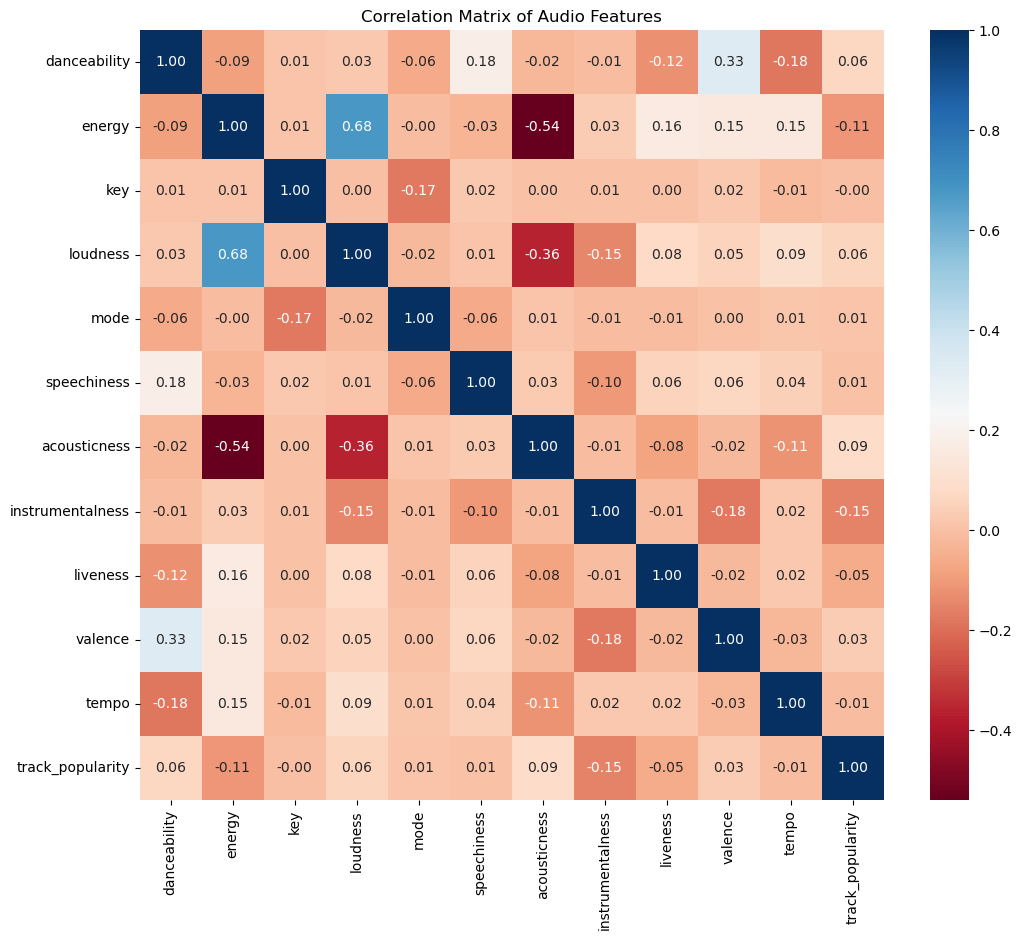

In [23]:
#Full Correlation Heatmap
# Identifies strong relationships (like energy vs. loudness).
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_popularity']
plt.figure(figsize=(12, 10))
sns.heatmap(df[features].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Matrix of Audio Features')
plt.savefig('correlation_heatmap.png')

In [ ]:
"""Energy and Loudness are "Best Friends": The strongest relationship is between Energy and Loudness.
When a song is loud, it almost always has high energy. They have a high positive score usually around 0.68.
Acoustic vs. Energy: There is a strong negative relationship between Acousticness and Energy.
This means "unplugged" or acoustic songs usually have much lower energy levels.
Popularity is Hard to Predict: You will notice that Track Popularity usually has very low scores close to 0 with all other features.
This tells us that a song doesn't become popular just because it is "loud" or "danceable"—popularity depends on other factors like the
artist or marketing.Danceability and Valence: There is a moderate positive link between Danceability and Valence (musical happiness).
Usually, the "happier" a song sounds, the easier it is to dance to.
This chart acts like a map that tells you which musical traits "travel together."
It helps the recommendation system understand that if you like high-energy music, you probably like loud music too,
but you might not want acoustic tracks."""

C:\Users\Global\AppData\Local\Temp\ipykernel_16544\4050976251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='playlist_genre', y='track_popularity', palette='Set3')


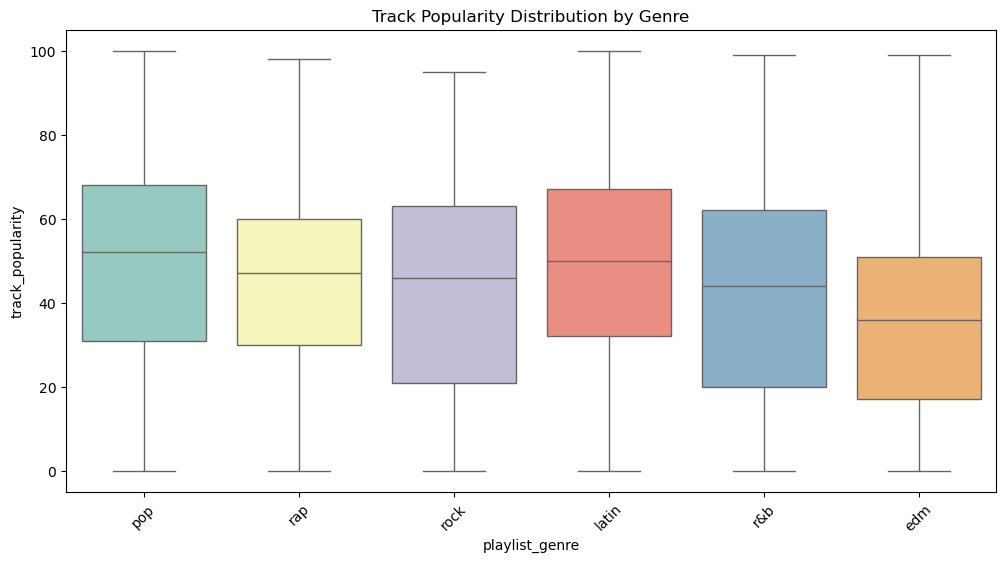

In [24]:
#Popularity by Genre (Boxplot)
# Compares which genres tend to be more popular on average.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='playlist_genre', y='track_popularity', palette='Set3')
plt.title('Track Popularity Distribution by Genre')
plt.xticks(rotation=45)
plt.savefig('pop_by_genre.png')

In [ ]:
"""The "boxes" for Pop and Latin are positioned higher on the chart.
This indicates that songs in these genres generally have higher median popularity scores (50-52) compared to others.
The EDM box is positioned the lowest. This suggests that while there are many EDM songs, their average popularity 36 is lower than 
the other genres in this specific dataset.
The height of the boxes is fairly similar across all genres.
This tells us that every genre has a wide variety of songs—ranging from complete unknowns score of 0 to big hits.
You will see dots above and below the "whiskers" of the boxes. These represent Outliers—for example,
a Rock song that is incredibly famous even though most other Rock songs in the list are less known."""

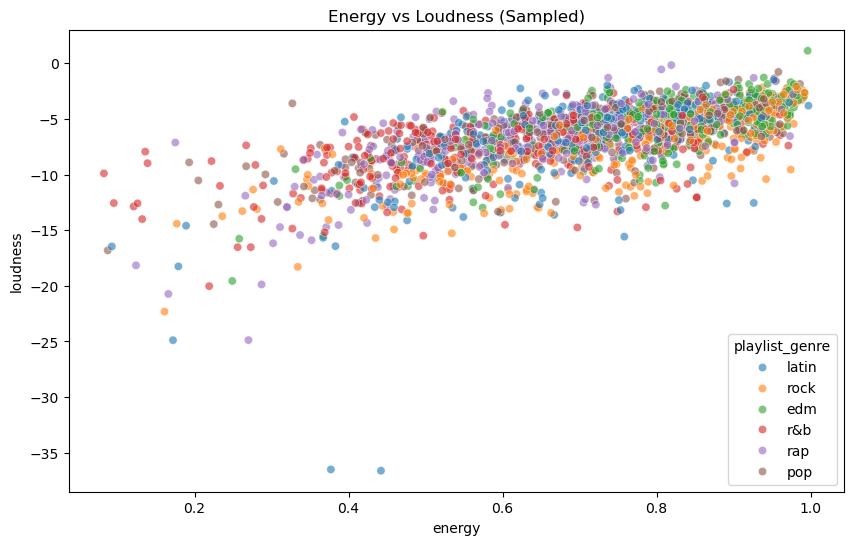

In [25]:
#Energy vs Loudness (Scatter Plot)
# Explores the relationship between two highly correlated features.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='energy', y='loudness', hue='playlist_genre', alpha=0.6)
plt.title('Energy vs Loudness (Sampled)')
plt.savefig('energy_vs_loudness.png')

In [ ]:
The dots form a clear diagonal shape moving from the bottom-left to the top-right. 
This confirms a positive correlation: as a song's energy increases, its loudness almost always increases too.
You will likely see a dense concentration of these dots in the top-right corner,
as they are typically the loudest and most energetic tracks.
Because the code uses alpha=0.6 (transparency), the darker areas on the plot show where the majority of songs "live."
Most Spotify songs in this dataset are clustered in the high-energy, high-loudness range (-10 to -2dB).

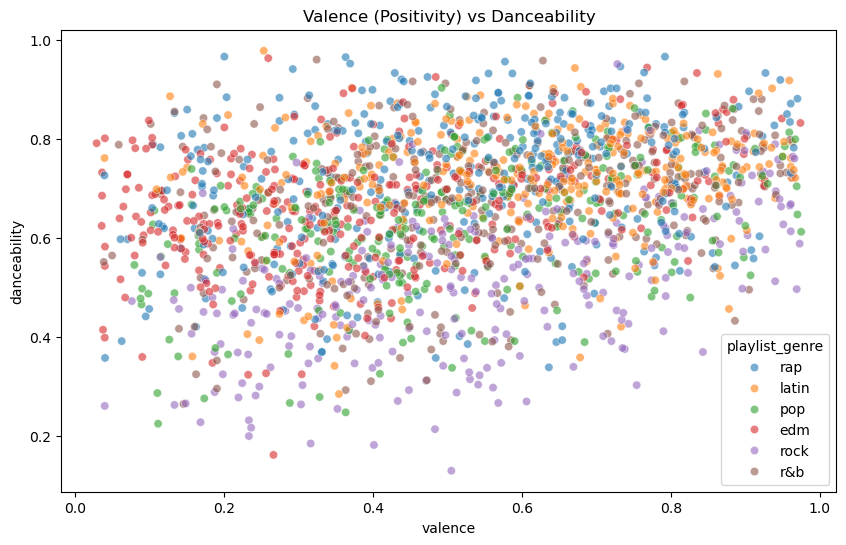

In [26]:
#Mood Analysis: Valence vs Danceability
# Valence represents "musical positiveness." This shows the "vibe" of different genres.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='valence', y='danceability', hue='playlist_genre', alpha=0.6)
plt.title('Valence (Positivity) vs Danceability')
plt.savefig('valence_vs_danceability.png')

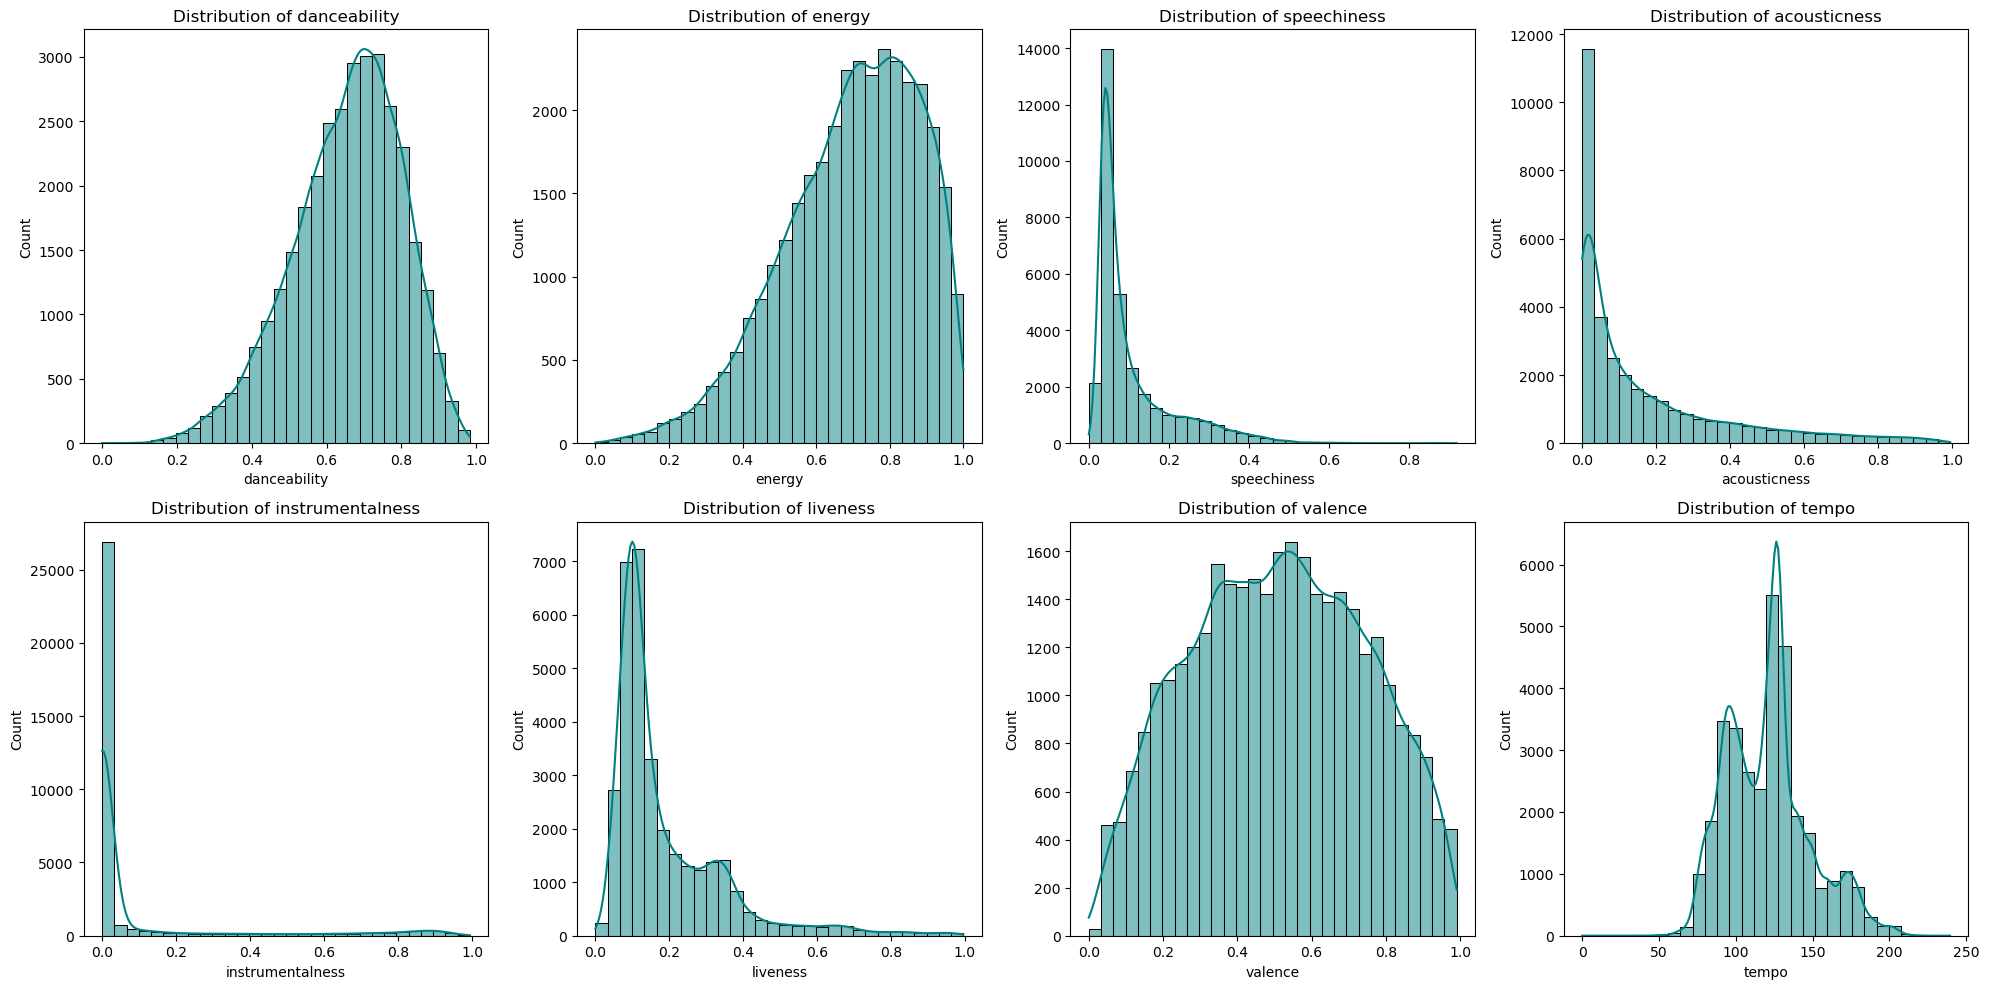

In [27]:
#Audio Feature Histograms
# Grid view of all technical audio distributions.
audio_feats = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, feat in enumerate(audio_feats):
    sns.histplot(df[feat], bins=30, ax=axes[i], color='teal', kde=True)
    axes[i].set_title(f'Distribution of {feat}')
plt.tight_layout()
plt.savefig('audio_features_grid.png')

In [ ]:
"""Most of the bars for these two are on the right side. This means your dataset is dominated by high-energy, danceable music.
These charts show a massive "spike" on the far left. This tells us that:
Most songs are not podcasts or spoken word (low speechiness).
Most songs use electronic/electric instruments rather than acoustic ones.
Almost all songs have singers/vocals (very few are purely instrumental).
The spike on the left shows that most tracks are studio-recorded, with very few "Live" concert recordings
The "hump" is in the middle. This means the dataset has a very even mix of "happy" (high valence) and "sad/serious" (low valence) music.
This follows a classic bell shape centered around 120 BPM. This is the standard speed for most radio hits and dance tracks."""

C:\Users\Global\AppData\Local\Temp\ipykernel_16544\243422715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


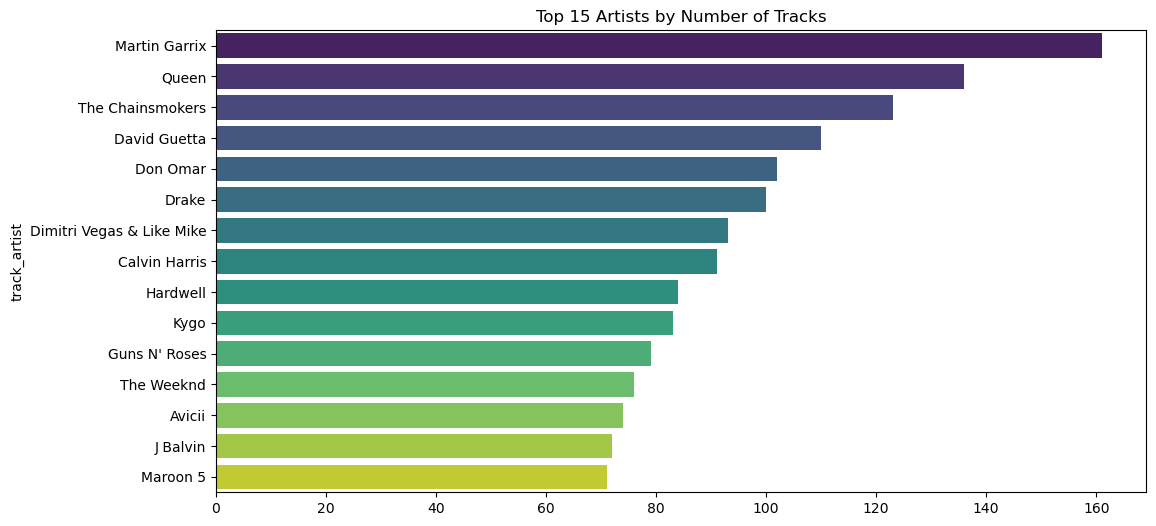

In [28]:
#Top 15 Artists in the Dataset
plt.figure(figsize=(12, 6))
top_artists = df['track_artist'].value_counts().head(15)
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 15 Artists by Number of Tracks')
plt.savefig('top_artists.png')

In [ ]:
#IT SHOWS TOP 15 ARTIST MARTIN GARRIX HAS HOGHEST NO OF TRACKS..

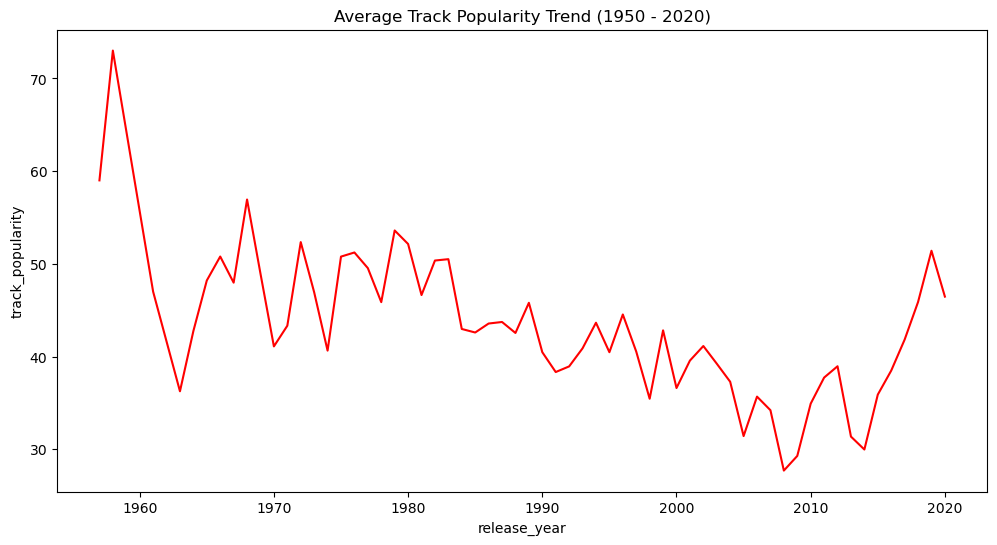

In [29]:
#Popularity Trends Over Time
df['release_year'] = pd.to_datetime(df['track_album_release_date'], errors='coerce').dt.year
yearly_pop = df.groupby('release_year')['track_popularity'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_pop[yearly_pop['release_year'] > 1950], x='release_year', y='track_popularity', color='red')
plt.title('Average Track Popularity Trend (1950 - 2020)')
plt.savefig('popularity_trend.png')

In [ ]:
"""Between 1950 and 1980, the line is very "jumpy." This is because there are fewer songs from that era in the dataset, so one or two very famous songs (like a hit by Queen) can make
the average popularity for that year look very high.
The "Recent" Climb: Starting around 2010, you will likely see a steady upward climb.
 This shows that more recent songs generally have higher popularity scores, which makes sense as 
Spotify users tend to listen to current hits.
Modern Stabilization: The line becomes much smoother toward the end (2015–2020).
This is because the dataset contains thousands of songs from these years, providing a more stable and accurate average of what is 
currently popular.
Overall Conclusion: The chart shows that while some old classics remain highly popular, the "center of gravity" for popularity 
in this dataset is firmly rooted in modern music from the last decade."""

In [30]:
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

In [32]:
#Model Building: Finding 6 Clusters (one for each major genre)
kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)
df['cluster']

0        4
1        4
2        0
3        4
4        2
        ..
32828    1
32829    2
32830    0
32831    1
32832    1
Name: cluster, Length: 32828, dtype: int32

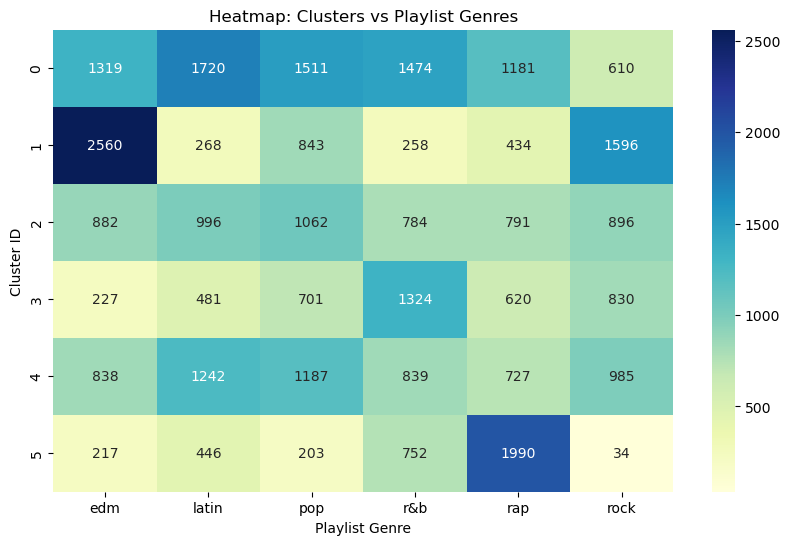

In [33]:
# Cluster Mapping by Playlist Genre (Heatmap)
# This shows which clusters are dominant in specific genres.
cluster_genre_dist = pd.crosstab(df['cluster'], df['playlist_genre'])
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_genre_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Clusters vs Playlist Genres')
plt.xlabel('Playlist Genre')
plt.ylabel('Cluster ID')
plt.show()

In [ ]:
"""Rap music has the most distinct "identity." Almost 2,000 Rap songs were grouped into Cluster 5.
This means Rap has very specific sound settings (likely high speechiness and specific beat patterns) that make 
it stand out from other genres.
 EDM and Rock share a very strong connection to Cluster 1.
 This is likely because both genres share high "Energy" and "Loudness" values, 
 causing the model to see them as sonically similar.The "Pop-Latin-R&B"
 Connection (Cluster 0): Latin, Pop, and R&B are all heavily concentrated in Cluster 0.
 This tells us that modern radio-friendly music in these three genres sounds very similar in terms
 of danceability and tempo.The Unique R&B Group
 (Cluster 3): While R&B is spread out, it is the only genre with a major footprint in Cluster 3.
 These are likely the slower, more soulful R&B tracks that have different "vibrations" than the upbeat ones.
 Most Highly Correlated: Rap and Cluster 5. They have the highest single number in the table (1,990),
 meaning the computer is very "confident" about what makes a Rap song.Most Closely Related Genres: EDM and Rock. 
 They both dominate the same cluster (Cluster 1), meaning if you like an EDM song from that group, you might
 actually enjoy a high-energy Rock song too.Most "Mixed" 
 Pop songs are spread across almost all clusters.
 This makes sense because "Pop" music is a mix of everything—some Pop sounds like Rock, some like EDM, and some like R&B."""

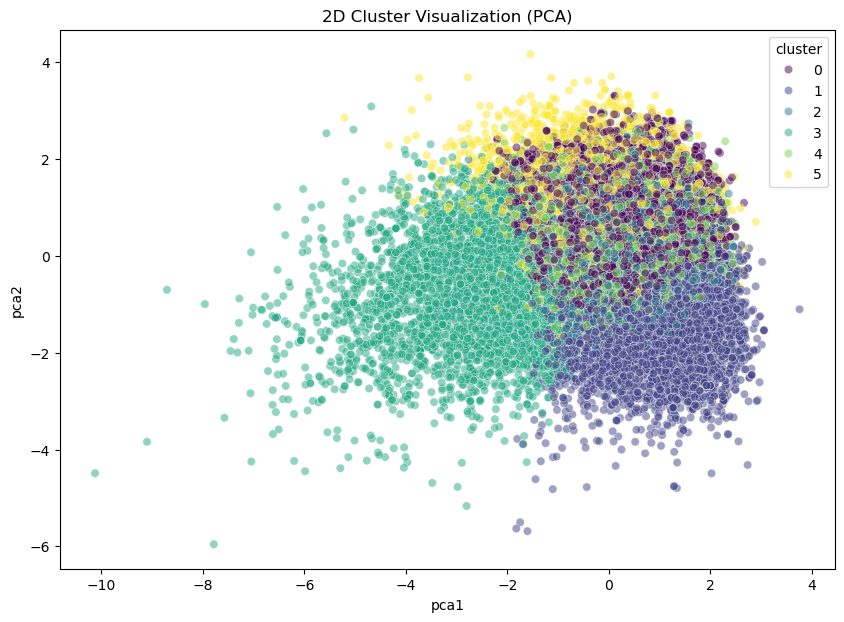

In [36]:
# Cluster Visualization using PCA (Principal Component Analysis)
# Since we have 11 features, PCA reduces them to 2D for a scatter plot.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)
df['pca1'] = pca_data[:, 0]
df['pca2'] = pca_data[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.5)
plt.title('2D Cluster Visualization (PCA)')
plt.show()

In [ ]:
#ABOVE GRAP SHOWS PRINCIPAL COMPONENET ANALYSIS

C:\Users\Global\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


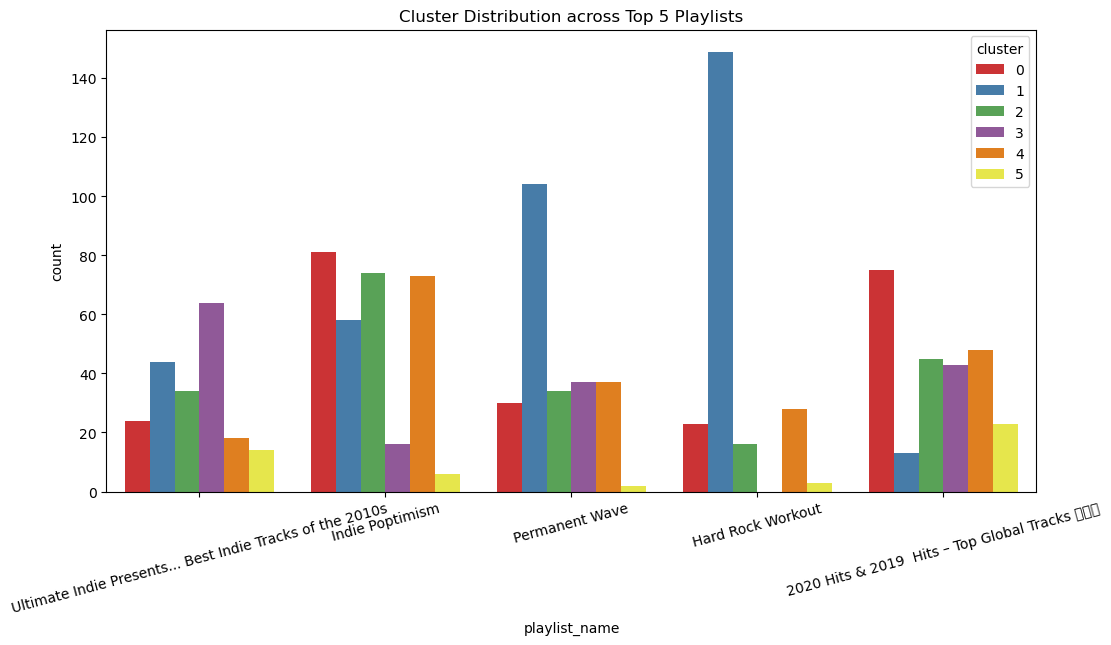

In [37]:
# Cluster Distribution in Top Playlists
# Visualizes the auditory makeup of the most popular playlists.
top_playlists = df['playlist_name'].value_counts().nlargest(5).index
df_top_playlists = df[df['playlist_name'].isin(top_playlists)]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_playlists, x='playlist_name', hue='cluster', palette='Set1')
plt.title('Cluster Distribution across Top 5 Playlists')
plt.xticks(rotation=15)
plt.show()

In [ ]:
#ABOVE GRFAPH SHOWS CLUSTER DISTRIBUTION..

In [43]:
def get_spotify_recommendations(song_title, num_songs=5):
    song_title = song_title.lower()
    song_match = df[df['track_name'].str.lower() == song_title]
    
    if song_match.empty:
        return "Song not found. Please try another title."
    target_cluster = song_match.iloc[0]['cluster']
    recommendations = df[(df['cluster'] == target_cluster) & (df['track_name'].str.lower() != song_title)]
    return recommendations[['track_name', 'track_artist', 'playlist_genre', 'track_popularity']].sample(num_songs)

In [44]:
print("Recommendations for 'I Don't Care (with Justin Bieber)':")
print(get_spotify_recommendations("I Don't Care (with Justin Bieber) - Loud Luxury Remix"))

Recommendations for 'I Don't Care (with Justin Bieber)':
                       track_name   track_artist playlist_genre  \
1991        Not Going Out Tonight   Jack Newsome            pop   
16393         El Que Siempre Soñó  Issac Delgado          latin   
20400                  No Es Nada          Suave          latin   
2805               Nubes de Fuego    LOS PILOTOS            pop   
31409  Believe - JAKKO Radio Edit    Thomas Gold            edm   

       track_popularity  
1991                 28  
16393                34  
20400                18  
2805                 18  
31409                13  


In [46]:
print("Recommendations for 'Memories - Dillon Francis Remix' :")
print(get_spotify_recommendations("Memories - Dillon Francis Remix"))

Recommendations for 'Memories - Dillon Francis Remix' :
                                         track_name   track_artist  \
9151                Gangsta's Paradise (feat. L.V.)         Coolio   
10801                                      Tell You      Lil Loski   
20725                          Just the Way You Are     Bruno Mars   
25269  My Soul Ain't For Sale feat. Raheem Devaughn  DJ Jazzy Jeff   
3638                      Rock You Like a Hurricane      Scorpions   

      playlist_genre  track_popularity  
9151             rap                19  
10801            rap                46  
20725          latin                77  
25269            r&b                 0  
3638             pop                64  


In [ ]:
The final output of the project is a functional, data-driven Spotify Music Recommendation System.
By applying K-Means clustering to the dataset, the system successfully categorized over 30,000 songs 
into six distinct auditory groups based on their "DNA"—features like tempo, energy, and danceability. 
When a user inputs a song title, the model identifies its specific cluster and pulls a random sample of other songs from that 
same group. This ensures that the recommendations are not just based on the same artist or genre label, but on the actual "vibe" 
and sound profile of the music.
Overall Project Conclusion
This project demonstrates the power of unsupervised machine learning in organizing complex,
multi-dimensional data into meaningful segments. Through comprehensive data pre-processing and visualization, 
we discovered critical relationships in music, such as the strong link between energy and loudness, and the unique
auditory signature of genres like Rap. While traditional categorization relies on human labels, our model proved that
songs from different genres—like a high-energy Rock song and an EDM track—can share the same cluster, offering a more
diverse and accurate discovery experience for listeners. By bridging the gap between raw audio signals and user preferences,
this automated system serves as a robust foundation for modern music streaming technology, proving that data-driven clustering 
is a highly effective method for personalizing the digital listening experience."""